In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar

In [2]:
# Set magics
# use autoreload to only reload the user-written functions 
%load_ext autoreload
%autoreload 1

%aimport model 
%aimport nosharing
%aimport vareps

In [3]:
eps_grid = np.linspace(0.0, 0.5, 25)   # preference strength
s_grid   = np.linspace(0.001, 0.2, 25) # search cost (avoid 0 exactly)
gamma = 0
results_base = []

In [5]:
prev_p1, prev_p2 = 0.5, 0.5

for eps in eps_grid:
    for s in s_grid:
        
        try:
            p1, p2, converged = model.solve_equilibrium(
                eps, s, gamma,
                p1_init=prev_p1,
                p2_init=prev_p2
            )
            
            # update warm start
            prev_p1, prev_p2 = p1, p2
            
            # compute objects
            theta = model.theta_star(p1, p2, eps, s, gamma)
            interior = model.check_interior(p1, p2, eps, s, gamma)["interior"]
            
            results_base.append({
                "eps": eps,
                "s": s,
                "p1": p1,
                "p2": p2,
                "theta": theta,
                "interior": interior,
                "converged": converged
            })
        
        except Exception as e:
            results_base.append({
                "eps": eps,
                "s": s,
                "p1": np.nan,
                "p2": np.nan,
                "theta": np.nan,
                "interior": False,
                "converged": False
            })

In [7]:
df = pd.DataFrame(results_base)
df["theta"] = df["theta"].clip(0, 1)
p1_mat = df.pivot(index="s", columns="eps", values="p1")
p2_mat = df.pivot(index="s", columns="eps", values="p2")
theta_mat = df.pivot(index="s", columns="eps", values="theta")

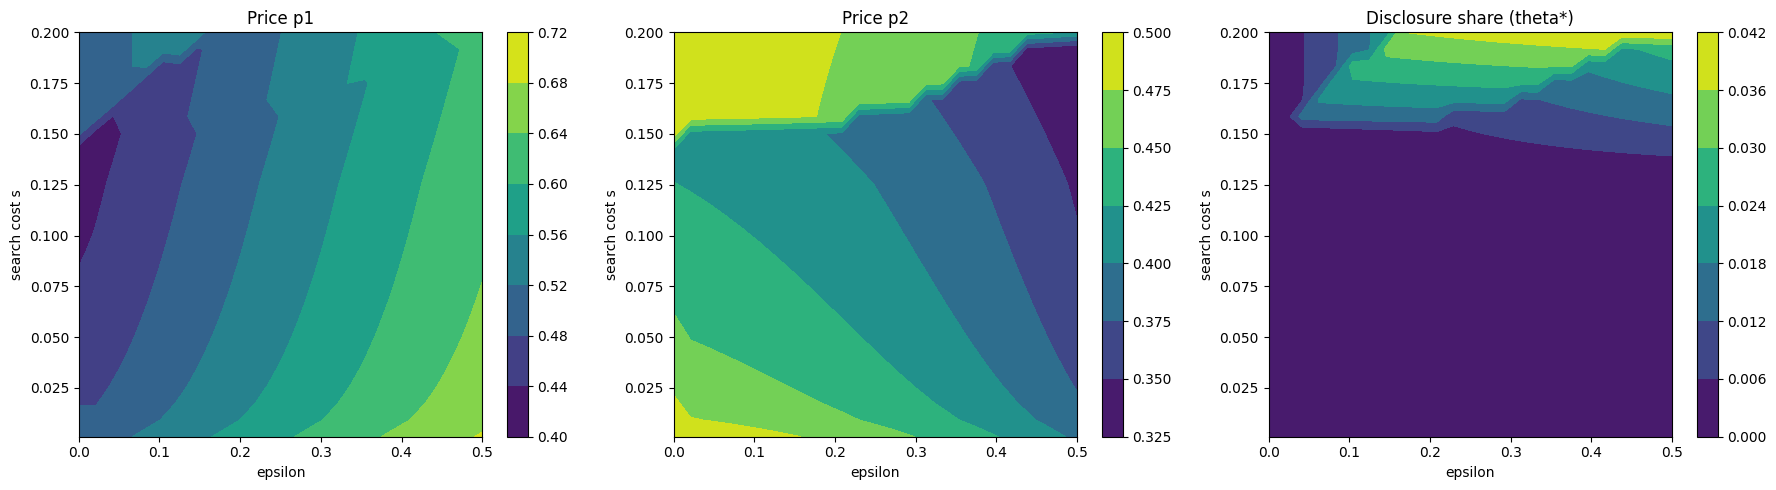

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].contourf(eps_grid, s_grid, p1_mat.values)
ax[0].set_title("Price p1")
ax[0].set_xlabel("epsilon")
ax[0].set_ylabel("search cost s")
ax[1].contourf(eps_grid, s_grid, p2_mat.values)
ax[1].set_title("Price p2")
ax[1].set_xlabel("epsilon")
ax[1].set_ylabel("search cost s")
ax[2].contourf(eps_grid, s_grid, theta_mat.values)
ax[2].set_title("Disclosure share (theta*)")
ax[2].set_xlabel("epsilon")
ax[2].set_ylabel("search cost s")
fig.colorbar(ax[0].collections[0], ax=ax[0])
fig.colorbar(ax[1].collections[0], ax=ax[1])
fig.colorbar(ax[2].collections[0], ax=ax[2])
plt.tight_layout()
plt.show()

In [17]:
eps_grid = np.linspace(0.0, 0.5, 25)   # preference strength
s_grid   = np.linspace(0.001, 0.2, 25) # search cost (avoid 0 exactly)
mu = 0.75
results_vareps = []

In [15]:
prev_p1, prev_p2 = 0.5, 0.5

for eps in eps_grid:
    for s in s_grid:
        
        try:
            p1, p2, converged = vareps.solve_equilibrium(
                eps, s, mu,
                p1_init=prev_p1,
                p2_init=prev_p2
            )
            
            # update warm start
            prev_p1, prev_p2 = p1, p2
            
            # compute objects
            theta = vareps.Theta_star(p1, p2, eps, s, mu)
            
            results_vareps.append({
                "eps": eps,
                "s": s,
                "p1": p1,
                "p2": p2,
                "theta": theta,
                "converged": converged
            })
        
        except Exception as e:
            results_vareps.append({
                "eps": eps,
                "s": s,
                "p1": np.nan,
                "p2": np.nan,
                "theta": np.nan,
                "converged": False
            })

In [19]:
df_var = pd.DataFrame(results_vareps)
df_var["theta"] = df["theta"].clip(0, 1)
p1_var = df_var.pivot(index="s", columns="eps", values="p1")
p2_var = df_var.pivot(index="s", columns="eps", values="p2")
theta_var = df_var.pivot(index="s", columns="eps", values="theta")

KeyError: 's'

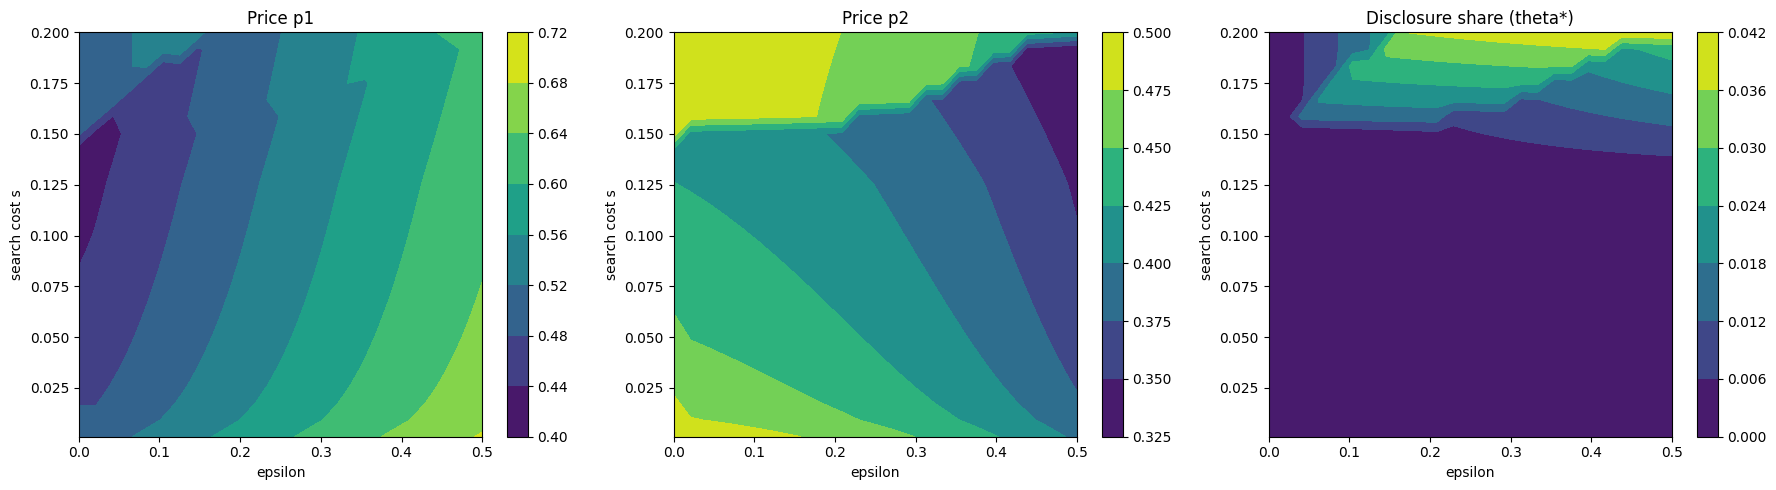

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].contourf(eps_grid, s_grid, p1_var.values)
ax[0].set_title("Price p1")
ax[0].set_xlabel("epsilon")
ax[0].set_ylabel("search cost s")
ax[1].contourf(eps_grid, s_grid, p2_var.values)
ax[1].set_title("Price p2")
ax[1].set_xlabel("epsilon")
ax[1].set_ylabel("search cost s")
ax[2].contourf(eps_grid, s_grid, theta_var.values)
ax[2].set_title("Disclosure share (theta*)")
ax[2].set_xlabel("epsilon")
ax[2].set_ylabel("search cost s")
fig.colorbar(ax[0].collections[0], ax=ax[0])
fig.colorbar(ax[1].collections[0], ax=ax[1])
fig.colorbar(ax[2].collections[0], ax=ax[2])
plt.tight_layout()
plt.show()

In [20]:
eps_grid = np.linspace(0.0, 0.5, 25)
s_grid   = np.linspace(0.001, 0.2, 25)

lam = 0.7   # share of consumers preferring firm 1

results_ext = []
prev_p1, prev_p2 = 0.5, 0.5

for eps in eps_grid:
    for s in s_grid:
        
        try:
            p1, p2, converged = vareps.solve_equilibrium(
                eps, s, lam,
                p1_init=prev_p1,
                p2_init=prev_p2
            )
            
            # warm start
            prev_p1, prev_p2 = p1, p2
            
            # disclosure components
            thetaA = vareps.theta_A_star(p1, p2, eps, s)
            thetaB = vareps.theta_B_star(p1, p2, eps, s)
            
            # aggregate disclosure
            Theta = lam * thetaA + (1 - lam) * thetaB
            
            results_ext.append({
                "eps": eps,
                "s": s,
                "p1": p1,
                "p2": p2,
                "Theta": Theta,
                "thetaA": thetaA,
                "thetaB": thetaB,
                "converged": converged
            })
        
        except Exception as e:
            results_ext.append({
                "eps": eps,
                "s": s,
                "p1": np.nan,
                "p2": np.nan,
                "Theta": np.nan,
                "thetaA": np.nan,
                "thetaB": np.nan,
                "converged": False
            })

In [21]:
df_ext = pd.DataFrame(results_ext)

# keep everything in [0,1]
df_ext["Theta"]  = df_ext["Theta"].clip(0, 1)
df_ext["thetaA"] = df_ext["thetaA"].clip(0, 1)
df_ext["thetaB"] = df_ext["thetaB"].clip(0, 1)

p1_mat = df_ext.pivot(index="s", columns="eps", values="p1")
p2_mat = df_ext.pivot(index="s", columns="eps", values="p2")
Theta_mat = df_ext.pivot(index="s", columns="eps", values="Theta")

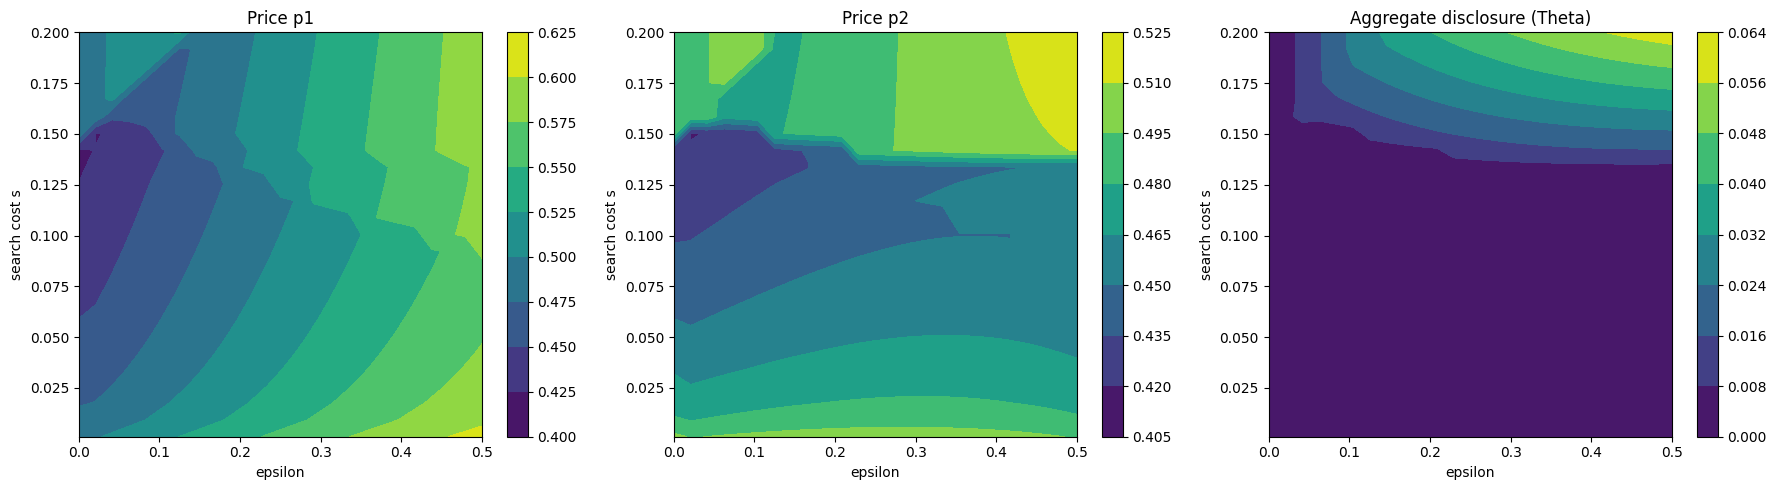

In [22]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# p1
c1 = ax[0].contourf(eps_grid, s_grid, p1_mat.values)
ax[0].set_title("Price p1")
ax[0].set_xlabel("epsilon")
ax[0].set_ylabel("search cost s")

# p2
c2 = ax[1].contourf(eps_grid, s_grid, p2_mat.values)
ax[1].set_title("Price p2")
ax[1].set_xlabel("epsilon")
ax[1].set_ylabel("search cost s")

# Theta
c3 = ax[2].contourf(eps_grid, s_grid, Theta_mat.values)
ax[2].set_title("Aggregate disclosure (Theta)")
ax[2].set_xlabel("epsilon")
ax[2].set_ylabel("search cost s")

# colorbars
fig.colorbar(c1, ax=ax[0])
fig.colorbar(c2, ax=ax[1])
fig.colorbar(c3, ax=ax[2])

plt.tight_layout()
plt.show()

In [183]:
# Define parameter cases #
gamma_grid = np.linspace(0, 1, 50)

cases = [
    (0.1, 0.1),
    (0.2, 0.1),
    (0.2, 0.2),
    (0.2, 0.3)
]

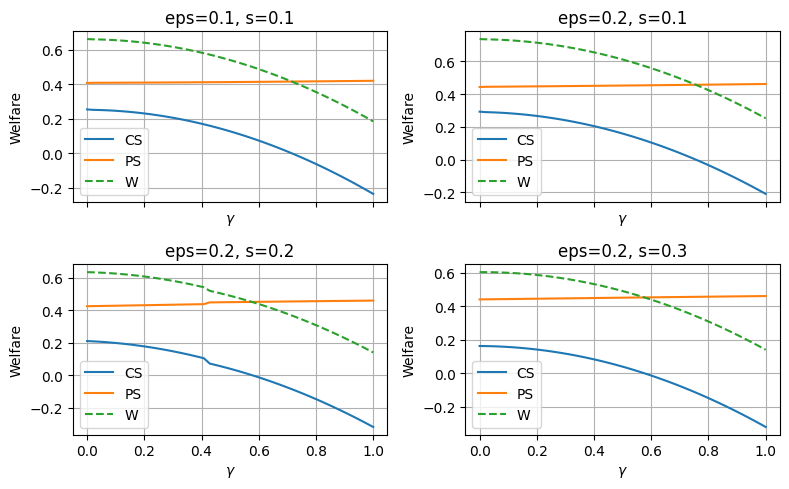

In [184]:
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid)
    ax.plot(gamma_grid, CS, label="CS")
    ax.plot(gamma_grid, PS, label="PS")
    ax.plot(gamma_grid, W, linestyle="--", label="W")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Welfare")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

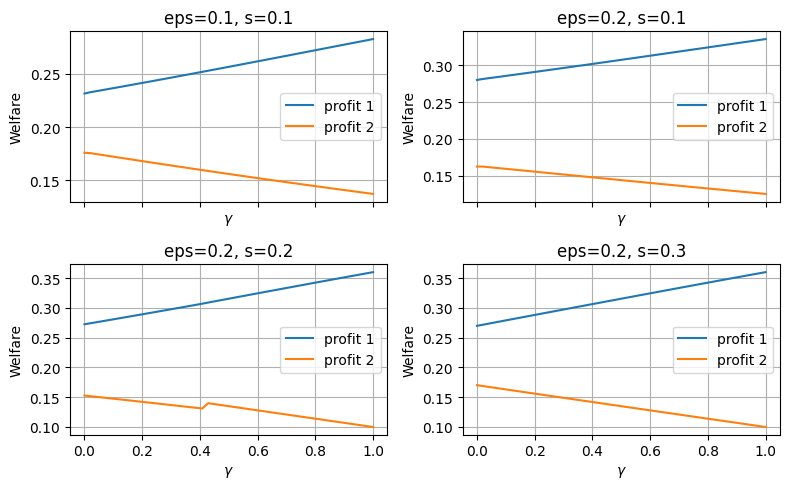

In [185]:
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid)
    ax.plot(gamma_grid, pi1, label="profit 1")
    ax.plot(gamma_grid, pi2, label="profit 2")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Welfare")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

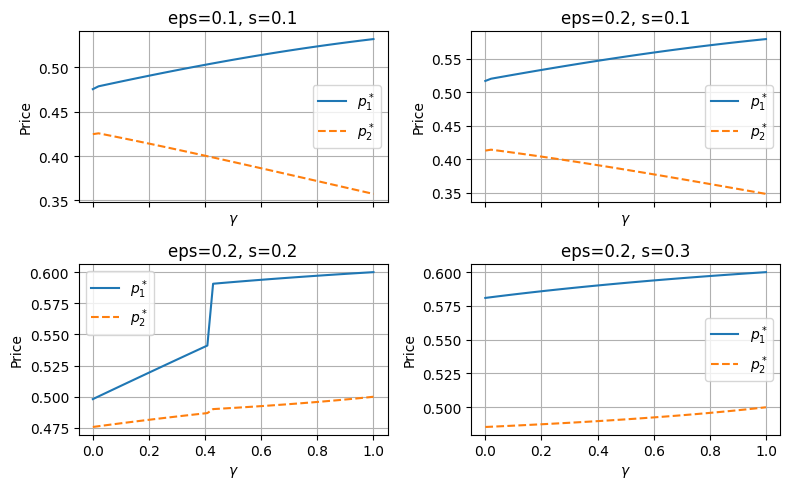

In [186]:
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid)
    
    ax.plot(gamma_grid, p1, label=r"$p_1^*$")
    ax.plot(gamma_grid, p2, linestyle="--", label=r"$p_2^*$")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Price")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [187]:
eps_grid = np.linspace(0.0, 0.5, 25)   # preference strength
s_grid   = np.linspace(0.001, 0.2, 25) # search cost (avoid 0 exactly)
results_nosharing = []

In [188]:
eps, s = 0.5, 0.19
p1, p2, converged = nosharing.solve_equilibrium(eps, s)

check = nosharing.check_interior(p1, p2, eps, s)

print(p1, p2)
print(check)

0.6161422670793864 0.33720861101363414
{'z_positive': True, 'support_ok': True, 'interior': True}


In [189]:
def compute_outcomes(eps, s):

    results = {}

    # --- No sharing ---
    p1_ns, p2_ns, _ = nosharing.solve_equilibrium(eps, s)
    pi1_ns = nosharing.profit1(p1_ns, p2_ns, eps, s)
    pi2_ns = nosharing.profit2(p1_ns, p2_ns, eps, s)

    results["No Sharing"] = {
        "p1": p1_ns,
        "p2": p2_ns,
        "pi1": pi1_ns,
        "pi2": pi2_ns,
        "CS": nosharing.consumer_surplus(p1_ns, p2_ns, eps, s),
        "PS": pi1_ns + pi2_ns,
        "W": nosharing.total_welfare(p1_ns, p2_ns, eps, s)
    }

    # --- Sharing, rational ---
    p1_r, p2_r, _ = model.solve_equilibrium(eps, s, gamma=0)
    pi1_r = model.profit1(p1_r, p2_r, eps, s, gamma=0)
    pi2_r = model.profit2(p1_r, p2_r, eps, s, gamma=0)

    results["Sharing (γ=0)"] = {
        "p1": p1_r,
        "p2": p2_r,
        "pi1": pi1_r,
        "pi2": pi2_r,
        "CS": model.consumer_surplus(p1_r, p2_r, eps, s, gamma=0),
        "PS": pi1_r + pi2_r,
        "W": model.total_welfare(p1_r, p2_r, eps, s, gamma=0)
    }

    # --- Sharing, naive ---
    p1_n, p2_n, _ = model.solve_equilibrium(eps, s, gamma=0.3)
    pi1_n = model.profit1(p1_n, p2_n, eps, s, gamma=0.3)
    pi2_n = model.profit2(p1_n, p2_n, eps, s, gamma=0.3)

    results["Sharing (γ=0.3)"] = {
        "p1": p1_n,
        "p2": p2_n,
        "pi1": pi1_n,
        "pi2": pi2_n,
        "CS": model.consumer_surplus(p1_n, p2_n, eps, s, gamma=0.3),
        "PS": pi1_n + pi2_n,
        "W": model.total_welfare(p1_n, p2_n, eps, s, gamma=0.3)
    }

    return pd.DataFrame(results).T

In [196]:
df = compute_outcomes(eps=0.2, s=0.19)
print(df.round(3))

                    p1     p2    pi1    pi2     CS     PS      W
No Sharing       0.501  0.489  0.274  0.155  0.210  0.430  0.639
Sharing (γ=0)    0.500  0.475  0.274  0.153  0.213  0.427  0.640
Sharing (γ=0.3)  0.532  0.484  0.299  0.137  0.150  0.436  0.586


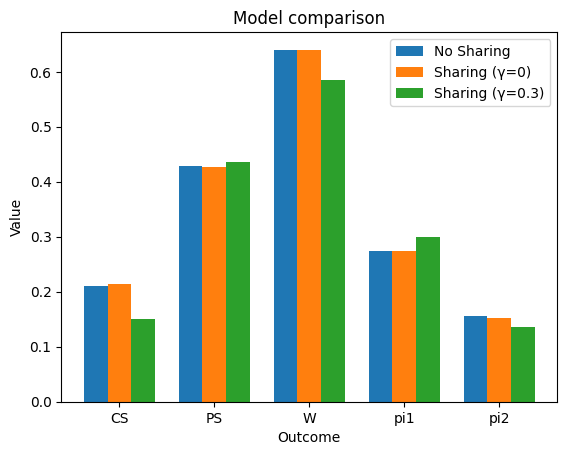

In [197]:
model.plot_comparison(df)